<a href="https://colab.research.google.com/github/vedikabhusari08/first_repo_vedika/blob/main/VedikaML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ML LAB 2

Vedika Bhusari

C_C1_13

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [2]:
from google.colab import files
uploaded = files.upload()

Saving housing.csv to housing (1).csv


In [3]:
import pandas as pd

filename = list(uploaded.keys())[0]
print("Loaded file:", filename)

df = pd.read_csv(filename)

print(df.columns.tolist())

Loaded file: housing (1).csv
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


In [4]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [6]:
df.shape

(20640, 10)

In [8]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [10]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [11]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [12]:
df.duplicated().sum()

np.int64(0)

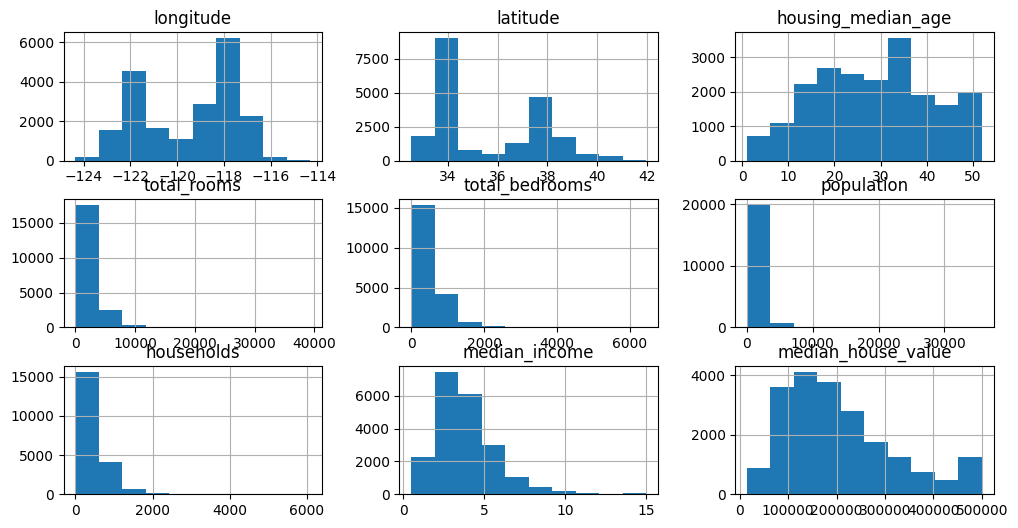

In [13]:
df.hist(figsize=(12,6))
plt.show()

In [14]:
df.drop("ocean_proximity", axis = 1 ,inplace = True)

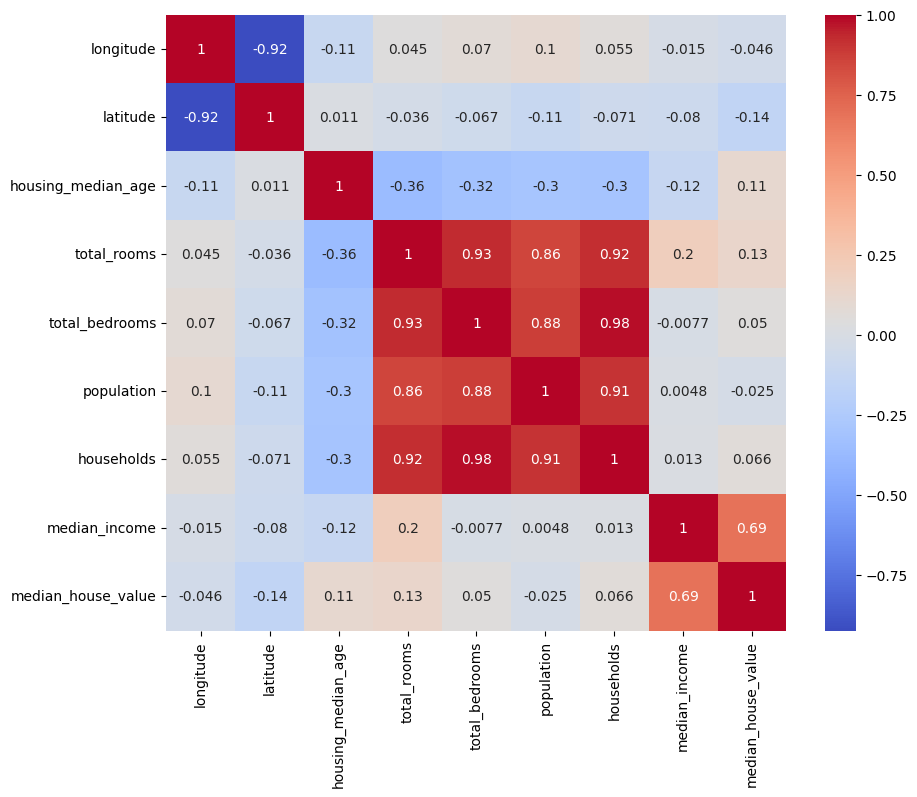

In [15]:
plt.figure(figsize=(10,8))


sns.heatmap(df.corr(),
            annot=True,
            cmap = "coolwarm")
plt.show()

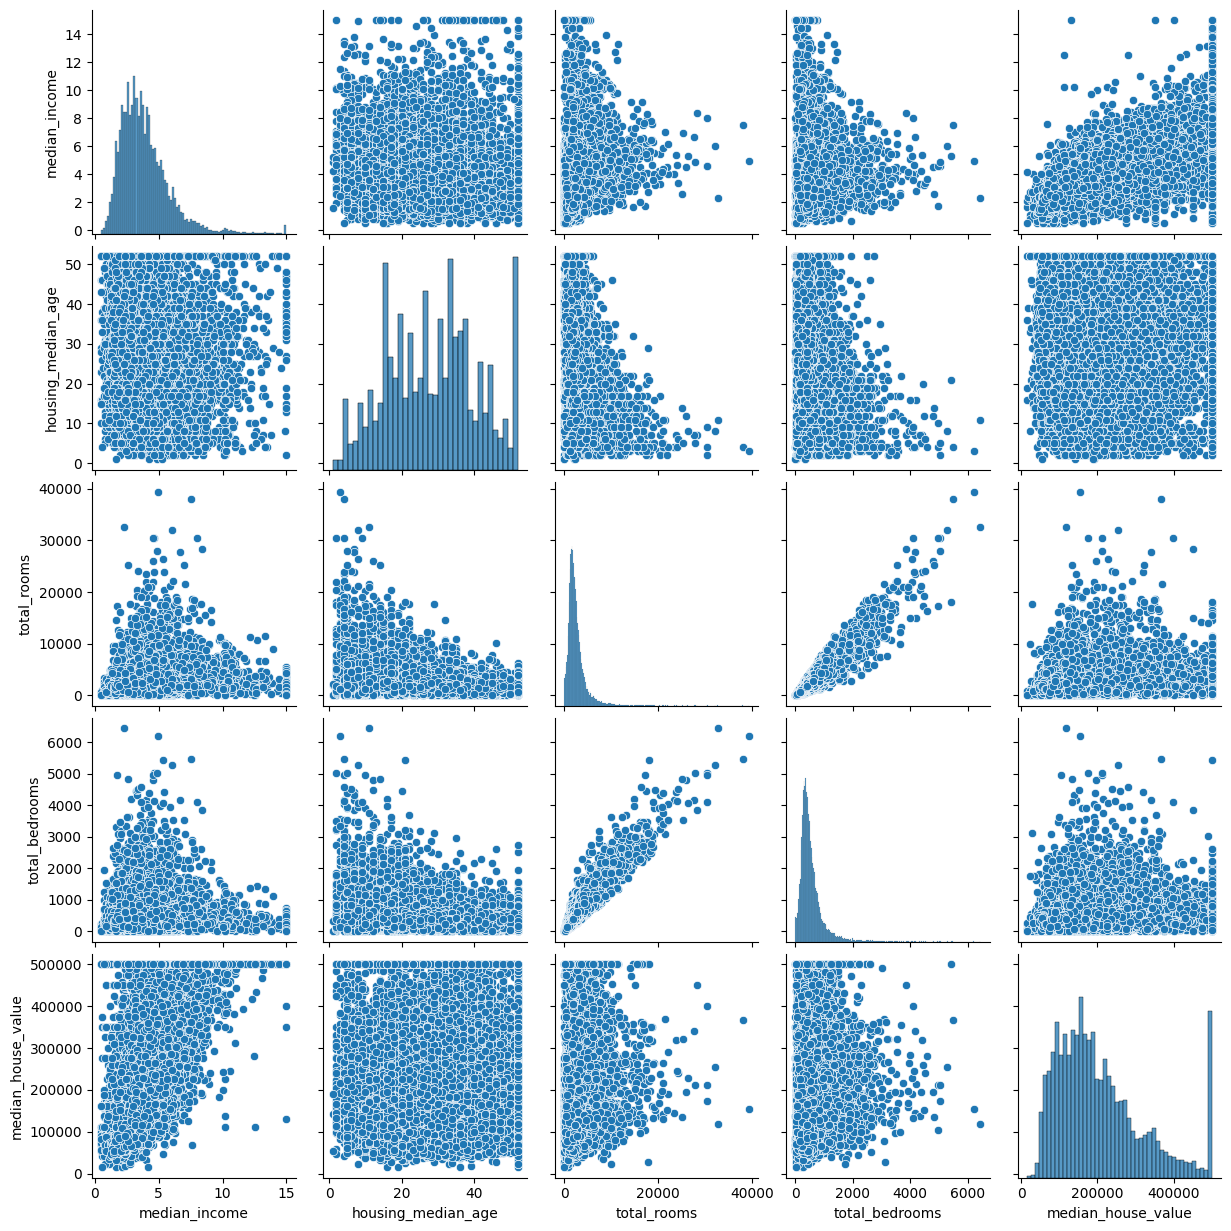

In [16]:
sns.pairplot(df[["median_income","housing_median_age","total_rooms","total_bedrooms","median_house_value"]])

plt.show()

In [17]:
X = df[["median_income"]]
y = df["median_house_value"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
slr = LinearRegression()
slr.fit(X_train, y_train)

LinearRegression()

In [20]:
y_pred = slr.predict(X_test)

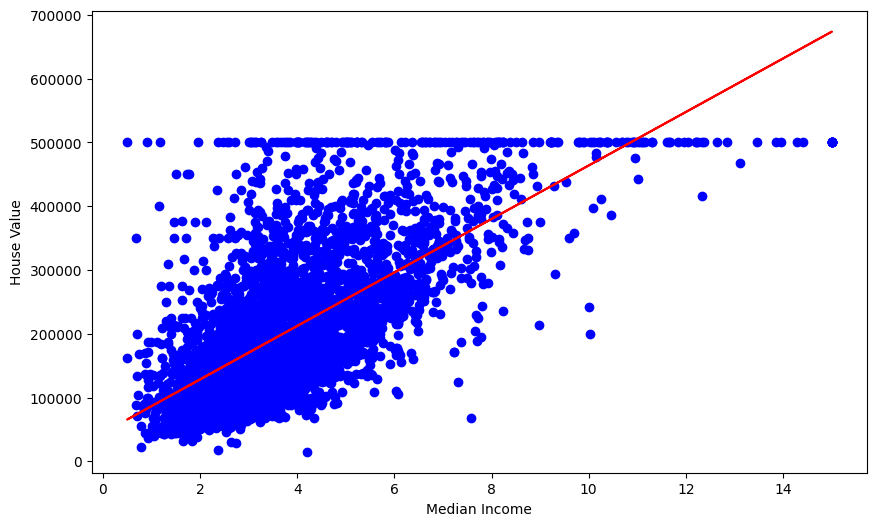

In [21]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue')
plt.plot(X_test, y_pred, color='red')

plt.xlabel('Median Income')
plt.ylabel("House Value")

plt.show()

Multiple Linear Regression

In [22]:
X = df.drop("median_house_value", axis = 1)
y = df["median_house_value"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
mlr = LinearRegression()
mlr.fit(X_train, y_train)

LinearRegression()

In [25]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

In [26]:

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 62990.86530093761
Mean Squared Error (MSE): 7091157771.76555
Root Mean Squared Error (RMSE): 84209.01241414454
R² Score: 0.45885918903846656


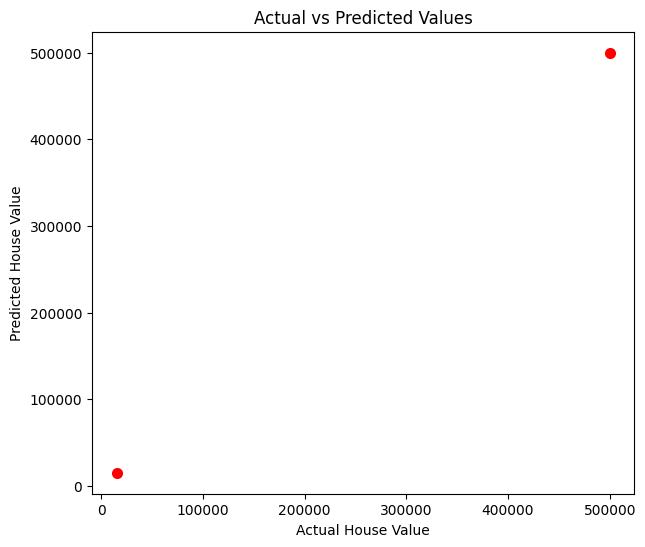

In [27]:
plt.figure(figsize=(7,6))

plt.scatter([y_test.min(), y_test.max()],
            [y_test.min(),y_test.max()],
            color = "red", linewidth=2)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted Values")

plt.show()

Hyperparameters Tuning

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [29]:
lr = LinearRegression()

In [30]:
lr_params = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}

In [31]:
grid_search = GridSearchCV(
    estimator=lr,
    param_grid=lr_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [32]:
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

In [33]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 score:", r2)

MAE : 62990.86530093761
MSE : 7091157771.76555
RMSE : 84209.01241414454
R2 score: 0.45885918903846656


In [34]:
print(best_model)

LinearRegression()


In [35]:
results = grid_search.cv_results_

for mean_score, params in zip(results['mean_test_score'], results['params']):
    print(params, "R2 =", round(mean_score, 4))

{'fit_intercept': True, 'positive': True} R2 = 0.5273
{'fit_intercept': True, 'positive': False} R2 = 0.6381
{'fit_intercept': False, 'positive': True} R2 = 0.5271
{'fit_intercept': False, 'positive': False} R2 = 0.5804


Ridge Regression

In [36]:
df = df.dropna()

X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [38]:
from sklearn.model_selection import GridSearchCV

In [39]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

ridge = Ridge()

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

print("Default Ridge R2 :", r2_score(y_test, ridge_pred))

Default Ridge R2 : 0.6138686241889177


In [40]:
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

In [41]:
grid_ridge = GridSearchCV(
    estimator=Ridge(),
    param_grid=param_grid,
    scoring='r2',
    cv=5
)

In [42]:
grid_ridge.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
             scoring='r2')

In [43]:
print("Best Alpha :", grid_ridge.best_params_)

Best Alpha : {'alpha': 10}


In [44]:
print(grid_ridge.best_score_)

0.6381322868510149
